# Environment Characterization (RL Equivalent of EDA) - Q-Learning #20

## Why This Notebook Exists

Reinforcement learning has no static dataset. There is no `X_train` / `y_train`
to preprocess and visualize before training. Instead, the agent generates its
own training data online by interacting with an environment via `env.step()`.

This notebook is the structural analogue of every other model's
`eda_<dataset>.ipynb`. Where standard supervised EDA characterizes the
**input distribution** before training, RL EDA characterizes the **environment
dynamics**:

| Standard EDA              | RL Env Characterization                       |
|---------------------------|-----------------------------------------------|
| Sample images / rows      | Render single frame per env                   |
| Feature distributions     | State-space bounds (Box ranges) + action card |
| Class balance             | Reward range, sparsity, shaping               |
| Sequence-length stats     | Max episode steps + termination conditions   |
| Random baseline accuracy  | **Random-policy baseline return** (anchors learning curves) |

## Three Environments Covered

| Env             | Used By       | Type                        | Solved Threshold |
|-----------------|---------------|-----------------------------|------------------|
| Taxi-v4         | V1 Tabular    | Discrete state (500 states) | ~7.7 mean return |
| CartPole-v1     | V2 DQN, V3 DDQN | Continuous state, dim 4   | 195+ over 100 ep |
| LunarLander-v3  | V4 Dueling, V5 PER | Continuous state, dim 8 | 200+ over 100 ep |

## Output Artifacts

- `data/raw/eda_envs/taxi_v4_sample_frame.txt` (ASCII render)
- `data/raw/eda_envs/cartpole_v1_sample_frame.png`
- `data/raw/eda_envs/lunarlander_v3_sample_frame.png`
- Random-policy baseline numbers (printed; referenced in V1-V5 learning-curve plots)

These baselines are the "from where" anchor every learning curve in the PyTorch
and TensorFlow pipelines builds against.

In [1]:
# Step 1: Setup - imports, paths, seed
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RANDOM_STATE = 113
np.random.seed(RANDOM_STATE)

# Output dir for rendered env frames
# Handle Jupyter being launched from project root OR from data-preperation/
cwd = Path.cwd()
if cwd.name == 'data-preperation':
    OUTPUT_DIR = cwd.parent / 'data' / 'raw' / 'eda_envs'
else:
    OUTPUT_DIR = cwd / 'data' / 'raw' / 'eda_envs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("ENV EDA SETUP")
print("=" * 60)
print(f"[1/4] gymnasium version: {gym.__version__}")
print(f"[2/4] numpy version:     {np.__version__}")
print(f"[3/4] RANDOM_STATE:      {RANDOM_STATE}")
print(f"[4/4] output dir:        {OUTPUT_DIR.resolve()}")

ENV EDA SETUP
[1/4] gymnasium version: 1.3.0
[2/4] numpy version:     2.3.5
[3/4] RANDOM_STATE:      113
[4/4] output dir:        C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\raw\eda_envs


In [2]:
# Step 2: Environment spec table - pull dimensions and solve thresholds from gymnasium spec
ENVS = ['Taxi-v4', 'CartPole-v1', 'LunarLander-v3']

print("=" * 60)
print("ENV SPEC TABLE")
print("=" * 60)

specs = {}
for env_id in ENVS:
    env = gym.make(env_id)

    # State space: Discrete (Taxi) vs Box (CartPole, LunarLander)
    if hasattr(env.observation_space, 'n'):
        state_desc = f"Discrete({env.observation_space.n})"
        state_dim = env.observation_space.n
        state_kind = 'discrete'
    else:
        shape = env.observation_space.shape
        state_desc = f"Box{shape}, dtype={env.observation_space.dtype}"
        state_dim = shape[0]
        state_kind = 'continuous'

    threshold = env.spec.reward_threshold
    threshold_str = f"{threshold:.1f}" if threshold is not None else "N/A"

    print(f"\n{env_id}")
    print(f"    state space:    {state_desc}")
    print(f"    action space:   Discrete({env.action_space.n})")
    print(f"    max steps:      {env.spec.max_episode_steps}")
    print(f"    solve thresh:   {threshold_str} (per gymnasium spec)")

    specs[env_id] = {
        'state_kind': state_kind,
        'state_dim': state_dim,
        'n_actions': env.action_space.n,
        'max_steps': env.spec.max_episode_steps,
        'threshold': threshold,
    }
    env.close()

print("\n" + "=" * 60)
print("Stored in `specs` dict for cells 4-6.")

ENV SPEC TABLE

Taxi-v4
    state space:    Discrete(500)
    action space:   Discrete(6)
    max steps:      200
    solve thresh:   8.0 (per gymnasium spec)

CartPole-v1
    state space:    Box(4,), dtype=float32
    action space:   Discrete(2)
    max steps:      500
    solve thresh:   475.0 (per gymnasium spec)

LunarLander-v3
    state space:    Box(8,), dtype=float32
    action space:   Discrete(4)
    max steps:      1000
    solve thresh:   200.0 (per gymnasium spec)

Stored in `specs` dict for cells 4-6.


Taxi-v4 (ASCII render at reset):
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




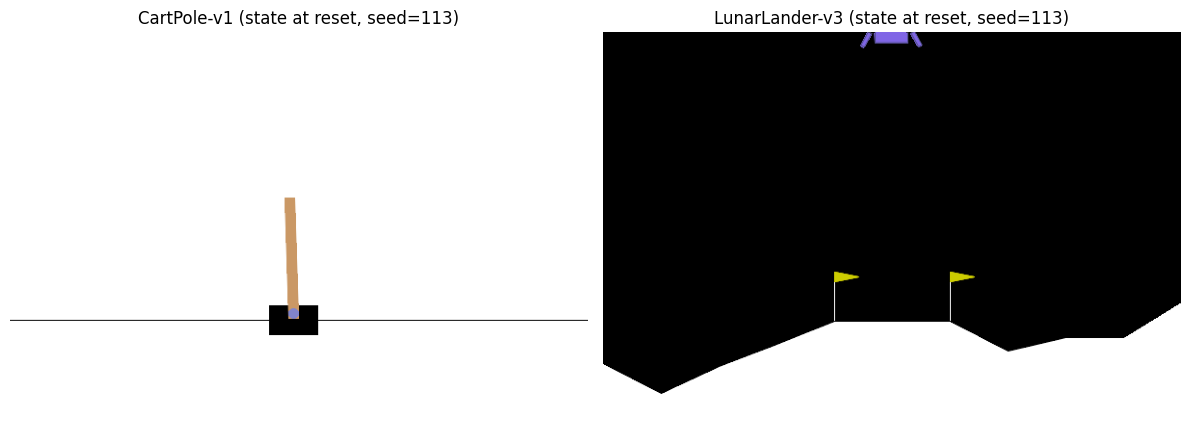


Frames saved:
    c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\raw\eda_envs\taxi_v4_sample_frame.txt
    c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\raw\eda_envs\cartpole_v1_sample_frame.png      shape=(400, 600, 3)
    c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\raw\eda_envs\lunarlander_v3_sample_frame.png   shape=(400, 600, 3)
    c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\raw\eda_envs\continuous_envs_grid.png            (combined)


In [3]:
# Step 3: Render single frame per env (state at reset, seeded for reproducibility)

# Taxi-v4: ASCII (no graphical render available)
env = gym.make('Taxi-v4', render_mode='ansi')
env.reset(seed=RANDOM_STATE)
taxi_ascii = env.render()
(OUTPUT_DIR / 'taxi_v4_sample_frame.txt').write_text(taxi_ascii)
env.close()

print("=" * 60)
print("Taxi-v4 (ASCII render at reset):")
print("=" * 60)
print(taxi_ascii)

# CartPole-v1 + LunarLander-v3: RGB arrays via pygame
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

env = gym.make('CartPole-v1', render_mode='rgb_array')
env.reset(seed=RANDOM_STATE)
cartpole_frame = env.render()
plt.imsave(OUTPUT_DIR / 'cartpole_v1_sample_frame.png', cartpole_frame)
axes[0].imshow(cartpole_frame)
axes[0].set_title(f'CartPole-v1 (state at reset, seed={RANDOM_STATE})')
axes[0].axis('off')
env.close()

env = gym.make('LunarLander-v3', render_mode='rgb_array')
env.reset(seed=RANDOM_STATE)
ll_frame = env.render()
plt.imsave(OUTPUT_DIR / 'lunarlander_v3_sample_frame.png', ll_frame)
axes[1].imshow(ll_frame)
axes[1].set_title(f'LunarLander-v3 (state at reset, seed={RANDOM_STATE})')
axes[1].axis('off')
env.close()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'continuous_envs_grid.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nFrames saved:")
print(f"    {OUTPUT_DIR / 'taxi_v4_sample_frame.txt'}")
print(f"    {OUTPUT_DIR / 'cartpole_v1_sample_frame.png'}      shape={cartpole_frame.shape}")
print(f"    {OUTPUT_DIR / 'lunarlander_v3_sample_frame.png'}   shape={ll_frame.shape}")
print(f"    {OUTPUT_DIR / 'continuous_envs_grid.png'}            (combined)")

In [4]:
# Step 4: Random-policy baselines - anchors V1-V5 learning curves later
N_EPISODES = 100

print("=" * 60)
print(f"RANDOM-POLICY BASELINES ({N_EPISODES} episodes per env)")
print("=" * 60)

random_baselines = {}
for env_id in ENVS:
    env = gym.make(env_id)
    env.action_space.seed(RANDOM_STATE)  # reproducible random action sampling

    returns = []
    for ep in range(N_EPISODES):
        env.reset(seed=RANDOM_STATE + ep)
        ep_return = 0.0
        terminated, truncated = False, False
        while not (terminated or truncated):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            ep_return += reward
        returns.append(ep_return)

    returns = np.array(returns)
    threshold = specs[env_id]['threshold']
    gap = threshold - returns.mean()

    random_baselines[env_id] = {
        'mean': float(returns.mean()),
        'std':  float(returns.std()),
        'min':  float(returns.min()),
        'max':  float(returns.max()),
        'returns': returns,
    }

    print(f"\n{env_id}")
    print(f"    mean return:    {returns.mean():>+9.2f}")
    print(f"    std:            {returns.std():>+9.2f}")
    print(f"    min / max:      {returns.min():>+9.2f}  /  {returns.max():>+9.2f}")
    print(f"    solve thresh:   {threshold:>+9.2f}")
    print(f"    gap to learn:   {gap:>+9.2f}  (V1-V5 must close this)")
    env.close()

print("\n" + "=" * 60)
print("Stored in `random_baselines` dict.")

RANDOM-POLICY BASELINES (100 episodes per env)

Taxi-v4
    mean return:      -780.32
    std:               +58.80
    min / max:        -929.00  /    -659.00
    solve thresh:       +8.00
    gap to learn:     +788.32  (V1-V5 must close this)

CartPole-v1
    mean return:       +21.08
    std:                +9.98
    min / max:          +8.00  /     +48.00
    solve thresh:     +475.00
    gap to learn:     +453.92  (V1-V5 must close this)

LunarLander-v3
    mean return:      -186.20
    std:              +108.81
    min / max:        -457.83  /      +9.84
    solve thresh:     +200.00
    gap to learn:     +386.20  (V1-V5 must close this)

Stored in `random_baselines` dict.


PER-STEP REWARD DISTRIBUTION (random policy, 20 episodes)

Taxi-v4
    total steps:    3,985
    unique rewards: 3
    reward range:   [-10.000, 20.000]
    mean per step:  -3.922
    structure:      DISCRETE / SPARSE (3 reward modes)

CartPole-v1
    total steps:    425
    unique rewards: 1
    reward range:   [1.000, 1.000]
    mean per step:  1.000
    structure:      CONSTANT (reward signal is episode length)

LunarLander-v3
    total steps:    1,781
    unique rewards: 1762
    reward range:   [-100.000, 131.522]
    mean per step:  -1.705
    structure:      DENSE / SHAPED (1762 unique values)


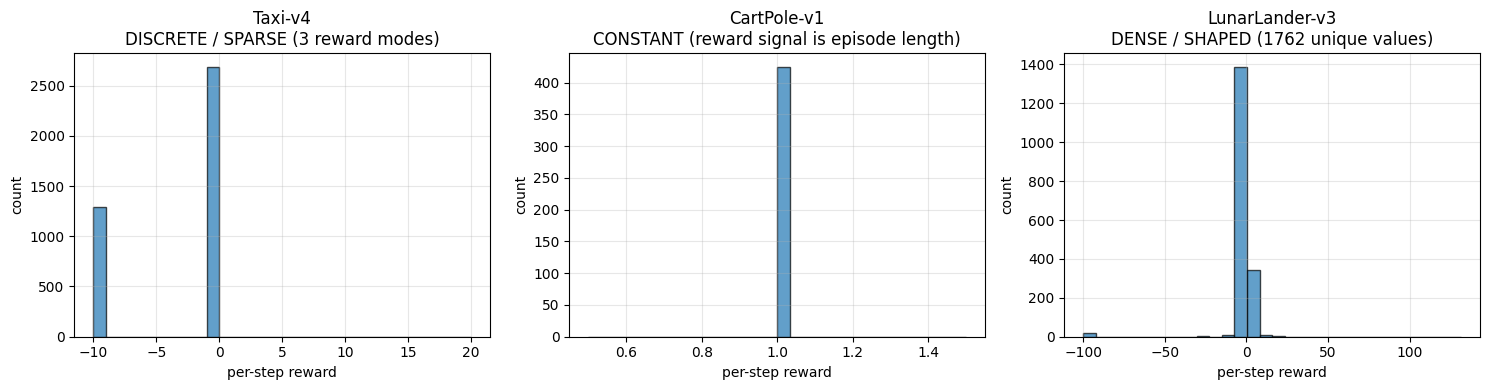


Figure saved to: c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\raw\eda_envs\reward_distributions.png


In [5]:
# Step 5: Per-step reward distributions (random policy, 20 episodes per env)
N_REWARD_EPISODES = 20

print("=" * 60)
print(f"PER-STEP REWARD DISTRIBUTION (random policy, {N_REWARD_EPISODES} episodes)")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, env_id in enumerate(ENVS):
    env = gym.make(env_id)
    env.action_space.seed(RANDOM_STATE)

    all_rewards = []
    for ep in range(N_REWARD_EPISODES):
        env.reset(seed=RANDOM_STATE + ep)
        terminated, truncated = False, False
        while not (terminated or truncated):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            all_rewards.append(reward)
    env.close()

    all_rewards = np.array(all_rewards)
    unique_count = len(np.unique(all_rewards))

    if unique_count == 1:
        kind = 'CONSTANT (reward signal is episode length)'
    elif unique_count <= 5:
        kind = f'DISCRETE / SPARSE ({unique_count} reward modes)'
    else:
        kind = f'DENSE / SHAPED ({unique_count} unique values)'

    axes[idx].hist(all_rewards, bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{env_id}\n{kind}')
    axes[idx].set_xlabel('per-step reward')
    axes[idx].set_ylabel('count')
    axes[idx].grid(True, alpha=0.3)

    print(f"\n{env_id}")
    print(f"    total steps:    {len(all_rewards):,}")
    print(f"    unique rewards: {unique_count}")
    print(f"    reward range:   [{all_rewards.min():.3f}, {all_rewards.max():.3f}]")
    print(f"    mean per step:  {all_rewards.mean():.3f}")
    print(f"    structure:      {kind}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'reward_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {OUTPUT_DIR / 'reward_distributions.png'}")